# Branch Lapse Rate Comparison

Calculate and compare temperature lapse rates along five glacier branches. The Maritime and Continental branches incorporate PACE station (intensive site) data in addition to pendant sensors.

**Branches:**
- **NWB** (Northwest Branch): A04, D01, D02, D04
- **C16** (C16 Branch): D02, E01, E03, E04  _(D02 shared with NWB)_
- **SWB** (Southwest Branch): B03, B02, B01
- **Maritime**: A04, A05, Windward2, A06, Windward1, A07, Divide  _(ordered by elevation; Windward1/2 and Divide are PACE stations)_
- **Continental**: Lee2, Lee1, A08, Divide  _(ordered by elevation; Lee1, Lee2, Divide are PACE stations)_

**Plots per branch:**
1. Lapse rate time series (raw + filtered)
2. Mean temperature by hour of day across sites

In [ ]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import matplotlib.ticker as mticker
from pathlib import Path

from jiflr import ROOT
from jiflr.data import select_sensors
from jiflr.utils import butterworth_filter, lapse_rate_ufunc

plt.style.use("default")
plt.ioff()

output_dir = Path("output")
output_dir.mkdir(exist_ok=True)

In [ ]:
# Load pendant data at native resolution
ds = xr.open_dataset(ROOT / "data/2025/processed/lvl1/lvl1_on_ice.nc")
ds = select_sensors(ds, height="2m", shielding="shielded")
ds = ds.isel(sensor_idx=~np.isnan(ds.latitude.values))
da = ds.temp_c  # native ~5-min resolution

# Load intensive (PACE) data for sites used in Maritime and Continental branches
# Keep at native 5-min resolution; resampled versions are derived below
ds_int = xr.open_dataset(ROOT / "data/2025/processed/lvl1/lvl1_intensive.nc")
ds_int = select_sensors(ds_int, height="2m", shielding="shielded")
INTENSIVE_SITES = ["Windward1", "Windward2", "Divide", "Lee1", "Lee2"]
ds_int = ds_int.where(ds_int.site_id.isin(INTENSIVE_SITES), drop=True)
da_int_raw = ds_int.temp_c  # native 5-min resolution

# Resampled versions used throughout
da_15min = da.resample(datetime="15min").mean()
da_int_15min = da_int_raw.resample(datetime="15min").mean()

da_1h = da.resample(datetime="1h").mean()
da_int_1h = da_int_raw.resample(datetime="1h").mean()

print(f"Pendant dataset dimensions: {dict(ds.sizes)}")
print(f"Available pendant sites: {sorted(ds.site_id.values.tolist())}")
print(f"Intensive sites loaded: {sorted(ds_int.site_id.values.tolist())}")

In [ ]:
# Define branches in geographic order along each transect
# Maritime sites ordered by elevation: A04=1237m, A05=1300m, Windward2=1405m, A06=1544m, Windward1=1751m, A07=1825m, Divide=1858m
# Continental sites ordered by elevation: Lee2=1400m, Lee1=1701m, A08=1767m, Divide=1858m
NWB_SITES = ["D01", "D02", "D04"]
C16_SITES = ["D02", "E01", "E03", "E04"]
SWB_SITES = ["B03", "B02", "B01"]
MARITIME_SITES = ["A04", "A05", "Windward2", "A06", "Windward1", "A07", "Divide"]
CONTINENTAL_SITES = ["Lee2", "Lee1", "A08", "Divide"]

BRANCHES = {
    "NWB": NWB_SITES,
    "C16": C16_SITES,
    "SWB": SWB_SITES,
    "Maritime": MARITIME_SITES,
    "Continental": CONTINENTAL_SITES,
}

# Branches that need intensive (PACE) site data merged in
INTENSIVE_BRANCHES = {"Maritime", "Continental"}

In [ ]:
def subset_transect(da_pendant, sites, da_intensive=None):
    """Select sites and drop timesteps with any missing data.

    For branches with PACE stations, pendant and intensive DataArrays are
    concatenated along sensor_idx before subsetting. Pass da_intensive only
    when needed.
    """
    if da_intensive is not None:
        da_combined = xr.concat([da_pendant, da_intensive], dim="sensor_idx")
    else:
        da_combined = da_pendant

    da_transect = da_combined.where(da_combined.site_id.isin(sites), drop=True)
    return da_transect.dropna(dim="datetime", how="any")


def build_branch_das(da_pendant, da_intensive, resolutions=("1h", "15min")):
    """Build branch DataArray dicts at one or more resolutions.

    Returns a dict keyed by resolution string, each value being a
    {branch_name: DataArray} dict.
    """
    # Resample inputs
    pendant_by_res = {r: da_pendant.resample(datetime=r).mean() for r in resolutions}
    intensive_by_res = {
        r: da_intensive.resample(datetime=r).mean() for r in resolutions
    }

    result = {r: {} for r in resolutions}
    for name, sites in BRANCHES.items():
        for r in resolutions:
            if name in INTENSIVE_BRANCHES:
                result[r][name] = subset_transect(
                    pendant_by_res[r], sites, da_intensive=intensive_by_res[r]
                )
            else:
                result[r][name] = subset_transect(pendant_by_res[r], sites)
    return result


branch_das_by_res = build_branch_das(
    da, da_int_raw, resolutions=("1h", "15min", "5min")
)
branch_das_1h = branch_das_by_res["1h"]
branch_das_15min = branch_das_by_res["15min"]
branch_das_5min = branch_das_by_res["5min"]

# branch_das kept as alias for hourly (used by downstream cells)
branch_das = branch_das_1h

for name, da_t in branch_das_1h.items():
    sites_found = sorted(da_t.site_id.values.tolist())
    t0 = str(da_t.datetime.values[0])[:19]
    t1 = str(da_t.datetime.values[-1])[:19]
    print(f"{name}: {t0} to {t1}, sites found: {sites_found}")

In [ ]:
# Filter configuration (hourly data, 6-hr low-pass)
FILTER_ORDER = 4
FILTER_FS = 1 / (60 * 60)  # hourly sampling frequency in Hz
FILTER_UPPER = 1 / (6 * 60 * 60)  # 6-hr cutoff


def compute_branch_lapse_rate(da_hourly, sites):
    """Compute lapse rate time series for a branch from hourly data.

    Convention: lapse rate = -dT/dz, positive when temperature decreases with elevation.

    Parameters
    ----------
    da_hourly : xr.DataArray
        Temperature already resampled to hourly intervals.

    Returns
    -------
    lapse_rate : xr.DataArray
        Lapse rate in deg C/m at each hourly timestep (positive = cooling with altitude).
    """
    site_mask = da_hourly.site_id.isin(sites).values
    slopes, _ = xr.apply_ufunc(
        lapse_rate_ufunc,
        da_hourly,
        da_hourly.elevation,
        site_mask,
        input_core_dims=[["datetime", "sensor_idx"], ["sensor_idx"], []],
        output_core_dims=[["datetime"], ["datetime"]],
        output_dtypes=[float, float],
        dask="forbidden",
    )
    # Negate: convention is lapse rate = -dT/dz, positive when temp decreases with elevation
    lapse_rate = xr.DataArray(
        -slopes,
        coords={"datetime": da_hourly.datetime},
        dims=["datetime"],
        attrs={"units": "degrees_C/m", "sites": ", ".join(sites)},
    )
    return lapse_rate


branch_lapse_rates = {}
# branch_das_15 kept as legacy name for the hourly DataArrays used by most plots
branch_das_15 = branch_das_1h

for name, sites in BRANCHES.items():
    print(f"Computing lapse rate for {name}...")
    lr = compute_branch_lapse_rate(branch_das_1h[name], sites)
    branch_lapse_rates[name] = lr
    print(f"  mean lapse rate: {lr.mean().values * 1000:.2f} deg C/km")

In [ ]:
def plot_branch_lapse_rate(lapse_rate, branch_name, output_path):
    """Plot raw and filtered lapse rate time series for one branch.

    Lapse rate convention: positive = temperature decreases with elevation.
    """
    lr_vals = lapse_rate.values
    valid = ~np.isnan(lr_vals)
    lr_filtered = np.full_like(lr_vals, np.nan)
    lr_filtered[valid] = butterworth_filter(
        lr_vals[valid], fs=FILTER_FS, order=FILTER_ORDER, upper=FILTER_UPPER
    )

    fig, ax = plt.subplots(figsize=(8, 4), dpi=200)
    ax.plot(
        lapse_rate.datetime.values,
        lr_vals * 1000,
        color="grey",
        lw=0.5,
        alpha=0.4,
        label="Raw",
    )
    ax.plot(
        lapse_rate.datetime.values,
        lr_filtered * 1000,
        color="steelblue",
        lw=1.5,
        label="Filtered (2 hr)",
    )
    ax.axhline(0, color="black", lw=0.8, ls="--", alpha=0.6)
    ax.set_ylim(-20, 20)
    ax.set_xlabel("Date")
    ax.set_ylabel("Lapse Rate (°C/km)\n[positive = cooling with altitude]")
    ax.set_title(
        f"{branch_name} Branch — Lapse Rate Over Time\nSites: {lapse_rate.attrs['sites']}"
    )
    ax.legend()
    fig.tight_layout()
    fig.savefig(output_path)
    plt.show()
    return fig


for name, lr in branch_lapse_rates.items():
    plot_branch_lapse_rate(lr, name, output_dir / f"{name}_lapse_rate_timeseries.png")

In [ ]:
def plot_hourly_mean_transect(
    da_transect,
    sites,
    title,
    output_path,
    lapse_rate,
    index_site=None,
    exclude_hours=None,
):
    """Plot mean temperature across a transect for each hour of day, split by lapse rate sign.

    Left panel: hours when lapse rate > 0 (normal).
    Right panel: hours when lapse rate < 0 (inverted).
    A single rainbow colorbar for hour-of-day is shared on the right.

    Sites are plotted in the order given by `sites` (geographic order).
    Each line represents one hour of the day, colored by a rainbow colormap.
    """
    present_sites = [s for s in sites if s in da_transect.site_id.values.tolist()]
    x_pos = np.arange(len(present_sites))

    site_elevations = {}
    for site in present_sites:
        match = da_transect.where(da_transect.site_id == site, drop=True)
        if "elevation" in match.coords and match.sensor_idx.size > 0:
            site_elevations[site] = float(match.elevation.values[0])

    temps = np.stack(
        [
            da_transect.where(da_transect.site_id == site, drop=True).values.ravel()
            for site in present_sites
        ],
        axis=1,
    )
    datetimes = pd.DatetimeIndex(da_transect.datetime.values)
    df = pd.DataFrame(temps, index=datetimes, columns=present_sites)

    date_start = datetimes.min().strftime("%Y-%m-%d")
    date_end = datetimes.max().strftime("%Y-%m-%d")

    lr_series = pd.Series(
        lapse_rate.values, index=pd.DatetimeIndex(lapse_rate.datetime.values)
    )
    lr_aligned = lr_series.reindex(
        df.index, method="nearest", tolerance=pd.Timedelta("30min")
    )

    if index_site is not None:
        assert index_site in present_sites, (
            f"index_site '{index_site}' not found in transect"
        )
        ylabel = f"Temperature relative to {index_site} (°C)"
    else:
        ylabel = "Mean Temperature (°C)"

    xticklabels = [
        f"{s}\n{site_elevations[s]:.0f} m" if s in site_elevations else s
        for s in present_sites
    ]

    # Single colormap spanning all 24 hours, shared across both panels
    hours = np.arange(24)
    n_hours = len(hours)
    colors = plt.get_cmap("rainbow", n_hours)(np.arange(n_hours))
    cmap = mcolors.ListedColormap(colors)
    bounds = np.arange(-0.5, n_hours + 0.5, 1)
    norm = mcolors.BoundaryNorm(bounds, ncolors=n_hours)
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])

    conditions = [
        ("Normal (LR > 0)", lr_aligned > 0),
        ("Inverted (LR < 0)", lr_aligned < 0),
    ]

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(12, 6),
        dpi=200,
        layout="constrained",
        sharey=True,
    )

    for ax, (cond_label, mask) in zip(axes, conditions):
        df_filt = df[mask.values]
        n_pts = mask.sum()

        hourly_mean = df_filt.groupby(df_filt.index.hour).mean()
        if exclude_hours:
            hourly_mean = hourly_mean.drop(
                index=[h for h in exclude_hours if h in hourly_mean.index]
            )

        if index_site is not None:
            hourly_mean = hourly_mean.subtract(hourly_mean[index_site], axis=0)

        for hour in hourly_mean.index:
            ax.plot(
                x_pos,
                hourly_mean.loc[hour].values,
                marker="o",
                color=colors[hour],
                lw=1.5,
                alpha=0.85,
            )

        ax.set_xlim(-0.5, len(present_sites) - 0.5)
        ax.set_xticks(x_pos)
        ax.set_xticklabels(xticklabels)
        ax.set_title(f"{cond_label}  (n={n_pts} timesteps)")

        ax.yaxis.set_major_locator(mticker.MultipleLocator(1))
        ax.yaxis.set_minor_locator(mticker.MultipleLocator(0.25))
        ax.grid(which="major", axis="y", linestyle="-", linewidth=0.8, alpha=0.6)
        ax.grid(which="minor", axis="y", linestyle=":", linewidth=0.5, alpha=0.4)

        if index_site is not None:
            ax.axvline(
                present_sites.index(index_site),
                color="black",
                linestyle="--",
                linewidth=1,
                alpha=0.5,
            )

    axes[0].set_ylabel(ylabel)
    cbar = fig.colorbar(
        sm,
        ax=axes[-1],
        ticks=np.arange(0, n_hours, 2),
        boundaries=bounds,
        spacing="uniform",
        pad=0.02,
    )
    cbar.set_label("Hour of Day")
    cbar.set_ticklabels([str(h) for h in range(0, n_hours, 2)])

    title_str = f"{title}\n{date_start} to {date_end}"
    if index_site is not None:
        title_str += f"  |  Reference site: {index_site}"
    fig.suptitle(title_str)

    fig.savefig(output_path)
    plt.show()
    return fig


BRANCH_INDEX_SITES = {
    "NWB": "D01",
    "C16": "E01",
    "SWB": "B01",
    "Maritime": "A04",
    "Continental": "Lee2",
}

for name, sites in BRANCHES.items():
    plot_hourly_mean_transect(
        branch_das_15[name],
        sites,
        title=f"{name} Branch Mean Temperature by Hour of Day",
        output_path=output_dir / f"{name}_hourly_mean.png",
        lapse_rate=branch_lapse_rates[name],
        index_site=BRANCH_INDEX_SITES[name],
    )


In [ ]:
for name, sites in BRANCHES.items():
    plot_hourly_mean_transect(
        branch_das_15[name],
        sites,
        title=f"{name} Branch Mean Temperature by Hour of Day",
        output_path=output_dir / f"{name}_hourly_mean_abs.png",
        lapse_rate=branch_lapse_rates[name],
    )


In [ ]:
def plot_hourly_mean_transect_combined(
    branch_das, branch_lapse_rates, branches, output_path, index_sites=None
):
    """Combined figure with 2 rows and one column per branch.

    Top row: LR > 0 (normal). Bottom row: LR < 0 (inverted).
    A single rainbow colorbar for hour-of-day is shared on the right.

    index_sites: dict mapping branch name -> index site id. When provided, temperatures
                 are plotted relative to that site (matching behavior of plot_hourly_mean_transect).
    """
    n_branches = len(branches)
    hours = np.arange(24)
    n_hours = len(hours)

    colors = plt.get_cmap("rainbow", n_hours)(np.arange(n_hours))
    cmap = mcolors.ListedColormap(colors)
    bounds = np.arange(-0.5, n_hours + 0.5, 1)
    norm = mcolors.BoundaryNorm(bounds, ncolors=n_hours)
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])

    fig, axes = plt.subplots(
        2,
        n_branches,
        figsize=(2.8 * n_branches + 1.0, 6.0),
        dpi=200,
        layout="constrained",
        sharey="col",
        sharex="col",
    )

    row_titles = ["Normal (LR > 0)", "Inverted (LR < 0)"]

    for col, (name, sites) in enumerate(branches.items()):
        da_transect = branch_das[name]
        lapse_rate = branch_lapse_rates[name]
        index_site = (index_sites or {}).get(name)

        present_sites = [s for s in sites if s in da_transect.site_id.values.tolist()]
        x_pos = np.arange(len(present_sites))

        if index_site is not None:
            assert index_site in present_sites, (
                f"index_site '{index_site}' not in branch '{name}'"
            )

        site_elevations = {}
        for site in present_sites:
            match = da_transect.where(da_transect.site_id == site, drop=True)
            if "elevation" in match.coords and match.sensor_idx.size > 0:
                site_elevations[site] = float(match.elevation.values[0])

        temps = np.stack(
            [
                da_transect.where(da_transect.site_id == s, drop=True).values.ravel()
                for s in present_sites
            ],
            axis=1,
        )
        datetimes = pd.DatetimeIndex(da_transect.datetime.values)
        df = pd.DataFrame(temps, index=datetimes, columns=present_sites)

        lr_series = pd.Series(
            lapse_rate.values, index=pd.DatetimeIndex(lapse_rate.datetime.values)
        )
        lr_aligned = lr_series.reindex(
            df.index, method="nearest", tolerance=pd.Timedelta("30min")
        )

        _label_abbrev = {"Windward1": "WW1", "Windward2": "WW2"}
        xticklabels = [
            f"{_label_abbrev.get(s, s)}\n{site_elevations[s]:.0f} m"
            if s in site_elevations
            else _label_abbrev.get(s, s)
            for s in present_sites
        ]

        if index_site is not None:
            ylabel = f"Temp rel. {index_site} (°C)"
        else:
            ylabel = "Mean Temp (°C)"

        conditions = [lr_aligned > 0, lr_aligned < 0]

        for row, (mask, row_title) in enumerate(zip(conditions, row_titles)):
            ax = axes[row, col]
            df_filt = df[mask.values]
            n_pts = mask.sum()

            hourly_mean = df_filt.groupby(df_filt.index.hour).mean()
            if index_site is not None:
                hourly_mean = hourly_mean.subtract(hourly_mean[index_site], axis=0)

            for i, hour in enumerate(hours):
                if hour not in hourly_mean.index:
                    continue
                ax.plot(
                    x_pos,
                    hourly_mean.loc[hour].values,
                    marker="o",
                    color=colors[i],
                    lw=1.0,
                    ms=2.5,
                    alpha=0.85,
                )

            ax.set_xlim(-0.5, len(present_sites) - 0.5)
            ax.set_xticks(x_pos)
            ax.set_xticklabels(xticklabels, fontsize=6)
            ax.yaxis.set_major_locator(mticker.MultipleLocator(2))
            ax.yaxis.set_minor_locator(mticker.MultipleLocator(0.5))
            ax.grid(which="major", axis="y", linestyle="-", linewidth=0.6, alpha=0.5)
            ax.grid(which="minor", axis="y", linestyle=":", linewidth=0.4, alpha=0.3)
            ax.tick_params(axis="both", labelsize=7)

            if col == 0:
                ax.set_ylabel(f"{row_title}\n{ylabel}", fontsize=7, fontweight="bold")

            if row == 0:
                ax.set_title(f"{name}", fontsize=9, fontweight="bold")

            ax.text(
                0.98,
                0.96,
                f"n={n_pts}",
                transform=ax.transAxes,
                fontsize=6,
                ha="right",
                va="top",
                color="grey",
            )

    cbar = fig.colorbar(
        sm,
        ax=axes,
        ticks=np.arange(0, n_hours, 1),
        boundaries=bounds,
        spacing="uniform",
        orientation="vertical",
        location="right",
        aspect=30,
        pad=0.02,
        shrink=0.9,
    )
    cbar.set_label("Hour of Day", fontsize=8)
    cbar.set_ticklabels([str(h) for h in range(0, n_hours)], fontsize=7)

    fig.savefig(output_path)
    return fig


BRANCH_INDEX_SITES = {
    "NWB": "D01",
    "C16": "D02",
    "SWB": "B01",
    "Maritime": "A04",
    "Continental": "Lee2",
}

plot_hourly_mean_transect_combined(
    branch_das_15,
    branch_lapse_rates,
    BRANCHES,
    output_path=output_dir / "all_branches_hourly_mean.png",
    index_sites=BRANCH_INDEX_SITES,
)

In [ ]:
def plot_rank_heatmap(da_transect, sites, branch_name, output_path, hour=None):
    """Heatmap of hourly site temperature rankings over time.

    Y-axis = rank (rank 1 = coldest at top). Each cell is colored by the site
    occupying that rank at that hour. Sites are colored by elevation using the
    plasma colormap (yellow = highest elevation, purple = lowest elevation).

    Parameters
    ----------
    hour : int or None
        If given, only timesteps at this hour of day are used. Otherwise all hours.
    """
    present_sites = [s for s in sites if s in da_transect.site_id.values.tolist()]

    # Get elevation per site
    site_elevations = {}
    for site in present_sites:
        match = da_transect.where(da_transect.site_id == site, drop=True)
        if match.sensor_idx.size > 0:
            site_elevations[site] = float(match.elevation.values[0])

    # Assign plasma colors by elevation: highest elev = lightest (yellow end)
    elev_vals = np.array([site_elevations.get(s, 0) for s in present_sites])
    elev_order = np.argsort(elev_vals)  # indices low->high
    site_color_map = {}
    cmap = plt.get_cmap("plasma")
    n_sites = len(present_sites)
    for rank_i, site_i in enumerate(elev_order):
        site_color_map[present_sites[site_i]] = cmap(rank_i / max(n_sites - 1, 1))

    # Build hourly temperature DataFrame
    temps = np.stack(
        [
            da_transect.where(da_transect.site_id == site, drop=True).values.ravel()
            for site in present_sites
        ],
        axis=1,
    )
    datetimes = pd.DatetimeIndex(da_transect.datetime.values)
    df = pd.DataFrame(temps, index=datetimes, columns=present_sites)
    df_hourly = df.resample("1h").mean()

    # Filter to requested hour of day if specified
    if hour is not None:
        df_plot = df_hourly[df_hourly.index.hour == hour]
        hour_label = f" — Hour {hour:02d}:00"
    else:
        df_plot = df_hourly
        hour_label = ""

    # Rank: rank 1 = coldest (ascending). Integer ranks — ties get min rank.
    ranks = df_plot.rank(axis=1, method="first", ascending=True).astype(int)

    n_times = len(df_plot)

    # Build RGBA image: shape (n_ranks, n_times, 4)
    img = np.ones((n_sites, n_times, 4))
    for t_i in range(n_times):
        for site in present_sites:
            r = ranks.loc[df_plot.index[t_i], site] - 1  # 0-indexed, 0=coldest
            img[r, t_i, :] = site_color_map[site]

    fig, ax = plt.subplots(figsize=(14, max(3, n_sites * 0.8 + 1.5)), dpi=150)

    ax.imshow(
        img,
        aspect="auto",
        origin="upper",  # rank 1 (coldest) at top
        extent=[0, n_times, n_sites + 0.5, 0.5],
        interpolation="nearest",
    )

    # X-axis as dates
    tick_step = max(1, n_times // 8)
    tick_positions = np.arange(0, n_times, tick_step)
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(
        [df_plot.index[i].strftime("%m-%d") for i in tick_positions],
        rotation=30,
        ha="right",
    )
    ax.set_xlim(0, n_times)

    ax.set_yticks(range(1, n_sites + 1))
    ax.set_yticklabels(
        [f"Rank {i}" + (" (coldest)" if i == 1 else "") for i in range(1, n_sites + 1)]
    )
    ax.set_ylim(n_sites + 0.5, 0.5)

    ax.set_xlabel("Date")
    ax.set_ylabel("Temperature Rank")
    ax.set_title(f"{branch_name} Branch — Temperature Rank Over Time{hour_label}")

    # Discrete colorbar: one color per site, ordered low->high elevation
    sites_low_to_high = [present_sites[i] for i in elev_order]
    colors_low_to_high = [site_color_map[s] for s in sites_low_to_high]
    cbar_cmap = mcolors.ListedColormap(colors_low_to_high)
    bounds = np.arange(-0.5, n_sites + 0.5, 1)
    norm = mcolors.BoundaryNorm(bounds, ncolors=n_sites)
    sm = cm.ScalarMappable(cmap=cbar_cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(
        sm,
        ax=ax,
        ticks=np.arange(n_sites),
        boundaries=bounds,
        spacing="uniform",
        pad=0.02,
    )
    cbar.set_label("Site (low to high elevation)")
    cbar.set_ticklabels(
        [
            f"{s}\n{site_elevations[s]:.0f} m" if s in site_elevations else s
            for s in sites_low_to_high
        ]
    )

    fig.tight_layout()
    fig.savefig(output_path)
    plt.show()
    return fig


for name, sites in BRANCHES.items():
    plot_rank_heatmap(
        branch_das_15[name],
        sites,
        branch_name=name,
        output_path=output_dir / f"{name}_rank_heatmap.png",
        hour=18,
    )

In [ ]:
for name, sites in BRANCHES.items():
    plot_rank_heatmap(
        branch_das_15[name],
        sites,
        branch_name=name,
        output_path=output_dir / f"{name}_rank_heatmap.png",
    )

In [ ]:
def plot_rank_heatmap_combined(
    branch_das, branch_lapse_rates, branches, output_path, hour=None
):
    """Combined rank heatmap: one row per branch, split by lapse rate sign.

    Left column: LR > 0 (normal). Right column: LR < 0 (inverted).
    Each cell is colored by the site occupying that rank at that timestep,
    with site colors assigned by elevation (plasma, low=dark, high=light).
    Grey bars indicate timesteps with no data. Each row has its own colorbar.
    """
    n_branches = len(branches)
    hour_label = f" — Hour {hour:02d}:00" if hour is not None else ""
    col_titles = ["Normal (LR > 0)", "Inverted (LR < 0)"]
    plasma = plt.get_cmap("plasma")

    fig, axes = plt.subplots(
        n_branches,
        2,
        figsize=(14, 1.8 * n_branches + 1),
        dpi=150,
        layout="constrained",
    )
    if n_branches == 1:
        axes = axes[np.newaxis, :]

    for row, (name, sites) in enumerate(branches.items()):
        da_transect = branch_das[name]
        lapse_rate = branch_lapse_rates[name]

        present_sites = [s for s in sites if s in da_transect.site_id.values.tolist()]
        n_sites = len(present_sites)

        # Elevation-based plasma colors
        site_elevations = {}
        for site in present_sites:
            match = da_transect.where(da_transect.site_id == site, drop=True)
            if match.sensor_idx.size > 0:
                site_elevations[site] = float(match.elevation.values[0])

        elev_vals = np.array([site_elevations.get(s, 0) for s in present_sites])
        elev_order = np.argsort(elev_vals)
        site_color_map = {
            present_sites[i]: plasma(k / max(n_sites - 1, 1))
            for k, i in enumerate(elev_order)
        }

        # Hourly temp DataFrame
        temps = np.stack(
            [
                da_transect.where(da_transect.site_id == s, drop=True).values.ravel()
                for s in present_sites
            ],
            axis=1,
        )
        datetimes = pd.DatetimeIndex(da_transect.datetime.values)
        df = pd.DataFrame(temps, index=datetimes, columns=present_sites)
        df_hourly = df.resample("1h").mean()
        if hour is not None:
            df_hourly = df_hourly[df_hourly.index.hour == hour]

        lr_series = pd.Series(
            lapse_rate.values, index=pd.DatetimeIndex(lapse_rate.datetime.values)
        )
        lr_aligned = lr_series.reindex(
            df_hourly.index, method="nearest", tolerance=pd.Timedelta("30min")
        )

        # Full time index shared across both columns
        full_times = df_hourly.index
        n_full = len(full_times)

        for col, (mask, col_title) in enumerate(
            zip(
                [lr_aligned > 0, lr_aligned < 0],
                col_titles,
            )
        ):
            ax = axes[row, col]

            if row == 0:
                ax.set_title(col_title, fontsize=9)
            if col == 0:
                ax.set_ylabel(name, fontsize=8, fontweight="bold")

            active_mask = mask.reindex(full_times).fillna(False).values

            df_active = df_hourly[active_mask].dropna(how="any")
            n_active = len(df_active)

            # Build image over the full time range; grey = no data
            grey = np.array([0.6, 0.6, 0.6, 1.0])
            img = np.tile(grey, (n_sites, n_full, 1))

            # Fill in rank colors for active timesteps
            if n_active > 0:
                ranks = df_active.rank(axis=1, method="first", ascending=True).astype(
                    int
                )
                active_indices = np.where(active_mask)[0]
                valid_active = [
                    i for i in active_indices if full_times[i] in df_active.index
                ]
                for t_idx in valid_active:
                    row_ranks = ranks.loc[full_times[t_idx]]
                    for site in present_sites:
                        r = int(row_ranks[site]) - 1
                        img[r, t_idx, :] = site_color_map[site]

            ax.imshow(
                img,
                aspect="auto",
                origin="upper",
                extent=[0, n_full, n_sites + 0.5, 0.5],
                interpolation="nearest",
            )

            tick_step = max(1, n_full // 5)
            tick_pos = np.arange(0, n_full, tick_step)
            ax.set_xticks(tick_pos)
            ax.set_xticklabels(
                [full_times[i].strftime("%m-%d") for i in tick_pos],
                fontsize=6,
                rotation=30,
                ha="right",
            )
            ax.set_xlim(0, n_full)

            ax.set_yticks(range(1, n_sites + 1))
            ax.set_yticklabels(
                [f"R{i}" + (" cold" if i == 1 else "") for i in range(1, n_sites + 1)],
                fontsize=6,
            )
            ax.set_ylim(n_sites + 0.5, 0.5)
            ax.tick_params(axis="x", labelsize=6)
            ax.text(
                0.99,
                0.97,
                f"n={n_active}",
                transform=ax.transAxes,
                fontsize=6,
                ha="right",
                va="top",
                color="white",
            )

        # Per-row colorbar on the right panel
        sites_low_to_high = [present_sites[i] for i in elev_order]
        colors_ordered = [site_color_map[s] for s in sites_low_to_high]
        cbar_cmap = mcolors.ListedColormap(colors_ordered)
        cb_bounds = np.arange(-0.5, n_sites + 0.5, 1)
        cb_norm = mcolors.BoundaryNorm(cb_bounds, ncolors=n_sites)
        cb_sm = cm.ScalarMappable(cmap=cbar_cmap, norm=cb_norm)
        cb_sm.set_array([])
        cbar = fig.colorbar(
            cb_sm,
            ax=axes[row, 1],
            ticks=np.arange(n_sites),
            boundaries=cb_bounds,
            spacing="uniform",
            aspect=15,
            pad=0.02,
            shrink=0.9,
        )
        cbar.ax.set_yticklabels([s for s in sites_low_to_high], fontsize=6)
        if row == 0:
            cbar.ax.set_title("low\u2192hi\nelev", fontsize=6, pad=2)

    fig.suptitle(
        f"Temperature Rank Heatmap \u2014 All Branches{hour_label}", fontsize=10
    )
    fig.savefig(output_path)
    plt.show()
    return fig


plot_rank_heatmap_combined(
    branch_das_15,
    branch_lapse_rates,
    BRANCHES,
    output_path=output_dir / "all_branches_rank_heatmap.png",
)


In [ ]:
import textalloc
from scipy import stats

BRANCH_COLORS = {
    "NWB": "steelblue",
    "C16": "darkorange",
    "SWB": "forestgreen",
    "Maritime": "crimson",
    "Continental": "purple",
}


def compute_branch_mean_temp(da_branch, lapse_rate, condition="all"):
    """Compute mean temperature per site for a given lapse rate condition.

    Parameters
    ----------
    da_branch : xr.DataArray
        Hourly branch temperature data (sensor_idx, datetime).
    lapse_rate : xr.DataArray
        Hourly branch lapse rate used to filter timesteps.
    condition : str
        'all', 'positive' (normal lapse rate), or 'negative' (inverted).

    Returns
    -------
    records : list of (site_id, elevation, mean_temp)
    n_hours : int
        Number of hourly timesteps included after filtering.
    """
    if condition == "all":
        lr_mask = xr.ones_like(lapse_rate, dtype=bool)
    elif condition == "positive":
        lr_mask = lapse_rate > 0
    else:  # negative
        lr_mask = lapse_rate < 0

    valid_times = lapse_rate.datetime.values[lr_mask.values]
    da_filt = da_branch.sel(datetime=da_branch.datetime.isin(valid_times))
    n_hours = int(len(valid_times))

    records = []
    for sensor_i in range(da_filt.sizes["sensor_idx"]):
        site = str(da_filt.site_id.values[sensor_i])
        elev = float(da_filt.elevation.values[sensor_i])
        vals = da_filt.isel(sensor_idx=sensor_i).values
        records.append((site, elev, float(np.nanmean(vals))))

    return records, n_hours


def plot_elevation_temp_scatter(records_by_branch, title, output_path):
    """Scatter plot of mean temperature vs elevation, one regression line per branch.

    records_by_branch values are (records, n_hours) tuples from compute_branch_mean_temp.
    """
    fig, ax = plt.subplots(figsize=(8, 4), dpi=150)

    all_label_x, all_label_y, all_label_texts, all_label_colors = [], [], [], []

    for branch_name, (records, n_hours) in records_by_branch.items():
        color = BRANCH_COLORS[branch_name]
        elevs = np.array([r[1] for r in records])
        temps = np.array([r[2] for r in records])

        ax.scatter(elevs, temps, color=color, s=60, zorder=3)

        slope, intercept, r, _, _ = stats.linregress(elevs, temps)
        x_range = np.linspace(elevs.min(), elevs.max(), 200)
        lr_km = -slope * 1000
        label = f"{branch_name} (n={n_hours} hrs): {lr_km:.2f} °C/km, R²={r**2:.2f}"
        ax.plot(
            x_range,
            slope * x_range + intercept,
            color=color,
            lw=1.5,
            ls="--",
            label=label,
            zorder=2,
        )

        for site, elev, mean_t in records:
            all_label_x.append(elev)
            all_label_y.append(mean_t)
            all_label_texts.append(site)
            all_label_colors.append(color)

    textalloc.allocate(
        ax,
        x=all_label_x,
        y=all_label_y,
        text_list=all_label_texts,
        textcolor=all_label_colors,
        textsize=8,
        draw_lines=True,
        linecolor="grey",
        linewidth=0.6,
        margin=0.01,
        min_distance=0.02,
    )

    ax.set_xlabel("Elevation (m)")
    ax.set_ylabel("Mean Temperature (°C)")
    ax.set_title(title)
    ax.grid(linestyle=":", linewidth=0.5, alpha=0.5)
    ax.legend(title="Branch regression", loc="upper right", fontsize=8)

    fig.tight_layout()
    fig.savefig(output_path)
    return fig


conditions = {
    "all": "All Periods",
    "positive": "Normal Lapse Rate Periods (LR > 0)",
    "negative": "Inverted Lapse Rate Periods (LR < 0)",
}

for condition, condition_label in conditions.items():
    records_by_branch = {
        name: compute_branch_mean_temp(
            branch_das_15[name], branch_lapse_rates[name], condition=condition
        )
        for name in BRANCHES
    }
    plot_elevation_temp_scatter(
        records_by_branch,
        title=f"Mean Temperature vs Elevation — {condition_label}",
        output_path=output_dir / f"elev_temp_scatter_{condition}.png",
    )

In [ ]:
def rank_array(da_transect, sites, hour=None):
    """Build a (n_sites, n_days) rank array for Kendall's W computation.

    Ranks are computed per day (or per hour-of-day bucket if hour is given),
    with rank 1 = coldest site. Each column is one day; each row is one site.

    Parameters
    ----------
    da_transect : xr.DataArray
        Hourly branch temperature data.
    sites : list of str
        Sites to include, in order.
    hour : int or None
        If given, use only timesteps at this hour of day.

    Returns
    -------
    rank_mat : np.ndarray, shape (n_sites, n_days)
    present_sites : list of str
        Sites actually found in the data, in the same row order as rank_mat.
    dates : np.ndarray of datetime.date
    """
    present_sites = [s for s in sites if s in da_transect.site_id.values.tolist()]

    temps = np.stack(
        [
            da_transect.where(da_transect.site_id == s, drop=True).values.ravel()
            for s in present_sites
        ],
        axis=1,
    )
    datetimes = pd.DatetimeIndex(da_transect.datetime.values)
    df = pd.DataFrame(temps, index=datetimes, columns=present_sites)

    if hour is not None:
        df = df[df.index.hour == hour]

    # Average within each calendar day, drop days with any NaN
    daily = df.groupby(df.index.date).mean().dropna(how="any")
    dates = daily.index.values

    # Rank per day: rank 1 = coldest (ascending), method='first' for integer ranks
    daily_ranks = daily.rank(axis=1, method="first", ascending=True).astype(int)

    # Shape: (n_sites, n_days)
    rank_mat = daily_ranks.values.T
    return rank_mat, present_sites, dates


def kendalls_w(rank_mat):
    """Compute Kendall's W (coefficient of concordance) from a rank matrix.

    Parameters
    ----------
    rank_mat : np.ndarray, shape (n_sites, n_days)
        rank_mat[i, j] = rank of site i on day j.

    Returns
    -------
    W : float
        Kendall's W in [0, 1]. 1 = perfect agreement across days.
    rank_sums : np.ndarray, shape (n_sites,)
        Sum of ranks across days for each site.
    """
    n_sites, m_days = rank_mat.shape
    rank_sums = rank_mat.sum(axis=1)  # sum across days for each site
    mean_rank_sum = rank_sums.mean()
    S = np.sum((rank_sums - mean_rank_sum) ** 2)
    W = 12 * S / (m_days**2 * (n_sites**3 - n_sites))
    return W, rank_sums


def analyze_kendalls_w(da_transect, sites, branch_name):
    """Compute Kendall's W for all hours and for the full dataset.

    Prints a summary table and returns the per-hour W dict and present sites.

    Parameters
    ----------
    da_transect : xr.DataArray
        Hourly branch temperature data.
    sites : list of str
    branch_name : str

    Returns
    -------
    best_hour : int
        Hour of day with the highest Kendall's W.
    hour_ws : dict of {int: float}
        W value keyed by hour of day.
    present_sites : list of str
    n_days_all : int
        Number of days used in the all-hours analysis.
    """
    print(f"\n{'=' * 60}")
    print(f"  {branch_name} Branch — Kendall's W Analysis")
    print(f"{'=' * 60}")

    # All-hours W
    rank_mat_all, present_sites, dates_all = rank_array(da_transect, sites)
    W_all, rank_sums_all = kendalls_w(rank_mat_all)
    n_sites, m_days = rank_mat_all.shape

    print(
        f"\nAll hours combined: W = {W_all:.4f}  (n_sites={n_sites}, n_days={m_days})"
    )
    print(f"  Site rank sums (rank 1 = coldest):")
    for site, rs in zip(present_sites, rank_sums_all):
        print(f"    {site:12s}  sum={rs:6.0f}  mean_rank={rs / m_days:.2f}")

    # Per-hour W
    print(f"\n  Per-hour Kendall's W:")
    print(f"  {'Hour':>5}  {'W':>7}  {'n_days':>7}  {'Coldest site'}")
    print(f"  {'-' * 45}")

    hour_ws = {}
    for h in range(24):
        rank_mat_h, _, dates_h = rank_array(da_transect, sites, hour=h)
        if rank_mat_h.shape[1] < 3:  # need enough days to be meaningful
            continue
        W_h, rank_sums_h = kendalls_w(rank_mat_h)
        hour_ws[h] = W_h
        coldest_site = present_sites[np.argmin(rank_sums_h)]
        print(f"  {h:02d}:00  {W_h:7.4f}  {rank_mat_h.shape[1]:7d}  {coldest_site}")

    best_hour = max(hour_ws, key=hour_ws.get)
    print(
        f"\n  Most consistent ranking: hour {best_hour:02d}:00 (W = {hour_ws[best_hour]:.4f})"
    )

    return best_hour, hour_ws, present_sites, m_days


branch_kendalls = {}
for name, sites in BRANCHES.items():
    best_hour, hour_ws, present_sites, n_days_all = analyze_kendalls_w(
        branch_das_15[name], sites, name
    )
    branch_kendalls[name] = {
        "best_hour": best_hour,
        "hour_ws": hour_ws,
        "sites": present_sites,
        "n_days_all": n_days_all,
    }

In [ ]:
def plot_inversion_heatmap(branch_lapse_rates, output_path):
    """Heatmap showing whether each branch had a normal or inverted lapse rate at each hour.

    Y-axis = branch. X-axis = time. Color = inverted (LR < 0) or normal (LR >= 0).
    Each branch's lapse rate is reindexed to a common hourly time axis.
    """
    branch_names = list(branch_lapse_rates.keys())

    # Build a common hourly time index spanning all branches
    all_times = pd.DatetimeIndex(
        sorted(
            set().union(
                *[
                    pd.DatetimeIndex(lr.datetime.values)
                    for lr in branch_lapse_rates.values()
                ]
            )
        )
    ).round("1h")
    all_times = all_times[~all_times.duplicated()]

    # Build (n_branches, n_times) boolean array: True = inverted (LR < 0)
    n_branches = len(branch_names)
    n_times = len(all_times)

    inversion = np.full((n_branches, n_times), np.nan)
    for i, name in enumerate(branch_names):
        lr = branch_lapse_rates[name]
        lr_series = pd.Series(
            lr.values, index=pd.DatetimeIndex(lr.datetime.values).round("1h")
        )
        lr_aligned = lr_series.reindex(all_times)
        inversion[i, :] = (lr_aligned.values < 0).astype(float)
        inversion[i, np.isnan(lr_aligned.values)] = np.nan

    # Colors: normal = steelblue, inverted = tomato, missing = light grey
    normal_color = np.array([0.27, 0.51, 0.71, 1.0])  # steelblue
    inverted_color = np.array([0.99, 0.35, 0.35, 1.0])  # tomato
    missing_color = np.array([0.88, 0.88, 0.88, 1.0])  # light grey

    img = np.empty((n_branches, n_times, 4))
    img[:] = missing_color
    img[inversion == 0] = normal_color
    img[inversion == 1] = inverted_color

    fig, ax = plt.subplots(figsize=(10, max(2.5, n_branches * 0.7 + 1.5)), dpi=300)

    ax.imshow(
        img,
        aspect="auto",
        origin="upper",
        extent=[0, n_times, n_branches + 0.5, 0.5],
        interpolation="nearest",
    )

    # X-axis: date labels
    tick_step = max(1, n_times // 10)
    tick_positions = np.arange(0, n_times, tick_step)
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(
        [all_times[i].strftime("%m-%d") for i in tick_positions],
        rotation=30,
        ha="right",
    )
    ax.set_xlim(0, n_times)

    ax.set_yticks(range(1, n_branches + 1))
    ax.set_yticklabels(branch_names)
    ax.set_ylim(n_branches + 0.5, 0.5)

    ax.set_xlabel("Date")
    ax.set_title("Lapse Rate Inversions by Branch")

    # Legend patches
    from matplotlib.patches import Patch

    legend_elements = [
        Patch(facecolor=normal_color, label="Normal (LR > 0)"),
        Patch(facecolor=inverted_color, label="Inverted (LR < 0)"),
        Patch(facecolor=missing_color, label="No data"),
    ]
    ax.legend(handles=legend_elements, loc="upper right", fontsize=9)

    fig.tight_layout()
    fig.savefig(output_path)
    return fig


plot_inversion_heatmap(branch_lapse_rates, output_dir / "inversion_heatmap.png")

In [ ]:
def plot_kendalls_w(branch_kendalls, output_path):
    """Plot Kendall's W by hour of day for each branch on a shared axis.

    Each branch is one line colored by BRANCH_COLORS. The best hour for each
    branch is marked with a dot. Legend includes n_days used for each branch.
    """
    hours = np.arange(24)

    fig, ax = plt.subplots(figsize=(10, 5), dpi=150)

    for branch_name, info in branch_kendalls.items():
        color = BRANCH_COLORS[branch_name]
        hour_ws = info["hour_ws"]
        n_days = info["n_days_all"]
        w_vals = np.array([hour_ws.get(h, np.nan) for h in hours])
        best_hour = info["best_hour"]

        ax.plot(
            hours, w_vals, color=color, lw=1.8, label=f"{branch_name} (n={n_days} days)"
        )
        ax.scatter([best_hour], [hour_ws[best_hour]], color=color, s=60, zorder=5)

    ax.set_xlabel("Hour of Day")
    ax.set_ylabel("Kendall's W")
    ax.set_title(
        "Kendall's W by Hour of Day — All Branches\n(rank 1 = coldest; W=1 means perfectly consistent daily ranking)"
    )
    ax.set_xticks(hours)
    ax.set_xlim(-0.5, 23.5)
    ax.set_ylim(bottom=0)
    ax.grid(linestyle=":", linewidth=0.5, alpha=0.5)
    ax.legend(title="Branch")

    fig.tight_layout()
    fig.savefig(output_path)
    return fig


plot_kendalls_w(branch_kendalls, output_dir / "kendalls_w_by_hour.png")

In [ ]:
def plot_temp_spread_all_branches(branch_das_15, branch_lapse_rates, output_path):
    """1x2 plot of mean temperature spread by hour of day for all branches.

    Columns: positive lapse rate periods | negative (inverted) lapse rate periods
    One line per branch, colored by BRANCH_COLORS.
    Spread = max(temp) - min(temp) across sites at each hourly timestep.
    Legend includes elevation range and mean lapse rate per branch.
    """
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=150, layout="constrained")

    col_titles = ["Normal Lapse Rate (LR > 0)", "Inverted Lapse Rate (LR < 0)"]
    conditions = [lambda lr: lr > 0, lambda lr: lr < 0]

    hours = np.arange(24)

    # Pre-compute per-branch legend metadata
    branch_meta = {}
    for name, da_branch in branch_das_15.items():
        elevs = da_branch.elevation.values
        elev_range = int(round(elevs.max() - elevs.min()))
        mean_lr_km = float(branch_lapse_rates[name].mean().values) * 1000
        branch_meta[name] = {"elev_range": elev_range, "mean_lr_km": mean_lr_km}

    for col, (condition_fn, title) in enumerate(zip(conditions, col_titles)):
        ax = axes[col]
        ax.set_title(title, fontsize=10)
        ax.set_xlabel("Hour of Day")
        ax.set_ylabel("Mean temp spread (°C)")
        ax.set_xticks(hours)
        ax.set_xlim(-0.5, 23.5)
        ax.yaxis.set_minor_locator(mticker.AutoMinorLocator())
        ax.grid(linestyle=":", linewidth=0.5, alpha=0.5)

        for name, da_branch in branch_das_15.items():
            lapse_rate = branch_lapse_rates[name]
            color = BRANCH_COLORS[name]
            meta = branch_meta[name]

            spread_da = da_branch.max(dim="sensor_idx") - da_branch.min(
                dim="sensor_idx"
            )
            spread_series = pd.Series(
                spread_da.values,
                index=pd.DatetimeIndex(da_branch.datetime.values),
            )
            lr_series = pd.Series(
                lapse_rate.values,
                index=pd.DatetimeIndex(lapse_rate.datetime.values),
            )
            lr_aligned = lr_series.reindex(spread_series.index)
            spread_filtered = spread_series.where(condition_fn(lr_aligned)).dropna()

            if spread_filtered.empty:
                continue

            hourly_mean = spread_filtered.groupby(spread_filtered.index.hour).mean()
            label = (
                f"{name}  "
                f"\u0394z={meta['elev_range']} m, "
                f"LR={meta['mean_lr_km']:.2g} °C/km"
            )
            ax.plot(
                hourly_mean.index.values,
                hourly_mean.values,
                color=color,
                lw=1.8,
                marker="o",
                ms=3,
                label=label,
            )

        ax.legend(title="Branch", fontsize=8)

    fig.suptitle("Temperature Spread Across Sites by Hour of Day", fontsize=12)
    fig.savefig(output_path)
    return fig


plot_temp_spread_all_branches(
    branch_das_15, branch_lapse_rates, output_dir / "temp_spread_by_hour.png"
)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker


def fit_diurnal_harmonic(x_hours, y):
    """
    Fit T(t) = a0 + a1 cos(wt) + b1 sin(wt)
    Returns dict with coefficients, amplitude, phase, and peak time.
    """
    omega = 2 * np.pi / 24.0

    X = np.column_stack(
        [np.ones_like(x_hours), np.cos(omega * x_hours), np.sin(omega * x_hours)]
    )

    coeffs, *_ = np.linalg.lstsq(X, y, rcond=None)
    a0, a1, b1 = coeffs

    amplitude = np.sqrt(a1**2 + b1**2)

    # Phase definition consistent with cosine form:
    # T = a0 + A cos(ωt - φ)
    phi = np.arctan2(b1, a1)

    # Convert phase to peak time (hours)
    t_peak = (phi / omega) % 24.0

    return {
        "a0": a0,
        "a1": a1,
        "b1": b1,
        "amplitude": amplitude,
        "phase_rad": phi,
        "t_peak": t_peak,
    }


def plot_hourly_temp_by_condition(
    da_branch, lapse_rate, sites, branch_name, output_path
):
    """1x2 plot using diurnal harmonic fits instead of splines."""

    present_sites = [s for s in sites if s in da_branch.site_id.values.tolist()]

    site_elevations = {}
    for site in present_sites:
        match = da_branch.where(da_branch.site_id == site, drop=True)
        if match.sensor_idx.size > 0:
            site_elevations[site] = float(match.elevation.values[0])

    # Color by elevation
    elev_vals = np.array([site_elevations.get(s, 0) for s in present_sites])
    elev_norm = (elev_vals - elev_vals.min()) / max(
        elev_vals.max() - elev_vals.min(), 1
    )

    cmap_low, cmap_high = 0.0, 0.9
    site_colors = {
        s: plt.get_cmap("plasma")(cmap_low + elev_norm[i] * (cmap_high - cmap_low))
        for i, s in enumerate(present_sites)
    }

    temps = np.stack(
        [
            da_branch.where(da_branch.site_id == s, drop=True).values.ravel()
            for s in present_sites
        ],
        axis=1,
    )

    datetimes = pd.DatetimeIndex(da_branch.datetime.values)
    df = pd.DataFrame(temps, index=datetimes, columns=present_sites)

    frac_hour = datetimes.hour + datetimes.minute / 60.0

    lr_series = pd.Series(
        lapse_rate.values, index=pd.DatetimeIndex(lapse_rate.datetime.values)
    )

    lr_aligned = lr_series.reindex(
        df.index, method="nearest", tolerance=pd.Timedelta("30min")
    )

    x_dense = np.linspace(0, 24, 500)
    omega = 2 * np.pi / 24.0

    fig, axes = plt.subplots(
        1, 2, figsize=(12, 5), dpi=150, layout="constrained", sharey=True
    )

    col_titles = ["Normal Lapse Rate (LR > 0)", "Inverted Lapse Rate (LR < 0)"]
    masks = [lr_aligned > 0, lr_aligned < 0]

    for col, (mask, title) in enumerate(zip(masks, col_titles)):
        ax = axes[col]

        df_filt = df[mask.values]
        fh_filt = frac_hour[mask.values]
        n_pts = mask.sum()

        fit_results = {}

        # --- Fit each site ---
        for site in present_sites:
            color = site_colors[site]
            elev = site_elevations.get(site, 0)
            label = f"{site} ({elev:.0f} m)"

            site_mean = df_filt[site].groupby(fh_filt).mean().dropna()
            if len(site_mean) < 6:
                continue

            x_pts = site_mean.index.values
            y_pts = site_mean.values

            # Scatter
            ax.plot(
                x_pts, y_pts, color=color, lw=0, marker="o", ms=2.5, alpha=0.3, zorder=2
            )

            # Harmonic fit
            fit = fit_diurnal_harmonic(x_pts, y_pts)
            fit_results[site] = fit

            y_fit = (
                fit["a0"]
                + fit["a1"] * np.cos(omega * x_dense)
                + fit["b1"] * np.sin(omega * x_dense)
            )

            ax.plot(x_dense, y_fit, color=color, lw=2.0, alpha=0.9, label=f"{label}")

        # --- Phase delay calculation ---
        if fit_results:
            # Use lowest elevation site as reference
            ref_site = min(fit_results.keys(), key=lambda s: site_elevations.get(s, 0))
            ref_phase = fit_results[ref_site]["phase_rad"]

            print(f"\n[{branch_name} | {title}] Reference site: {ref_site}")

            for site, fit in fit_results.items():
                dphi = fit["phase_rad"] - ref_phase

                # wrap to [-pi, pi]
                dphi = (dphi + np.pi) % (2 * np.pi) - np.pi

                dt_hours = dphi / omega

                print(
                    f"{site:10s} | Amp={fit['amplitude']:.2f} "
                    f"| Peak={fit['t_peak']:.2f} h "
                    f"| Delay={dt_hours:+.2f} h"
                )

        ax.set_title(title, fontsize=10)
        ax.set_xlabel("Hour of Day")
        ax.set_ylabel("Mean Temperature (°C)")
        ax.set_xticks(np.arange(0, 24, 2))
        ax.set_xlim(0, 24)

        ax.yaxis.set_minor_locator(mticker.AutoMinorLocator())
        ax.grid(linestyle=":", linewidth=0.5, alpha=0.5)

        ax.text(
            0.02, 0.96, f"n={n_pts} obs", transform=ax.transAxes, fontsize=8, va="top"
        )

        ax.legend(title="Site", fontsize=8)

    fig.suptitle(
        f"{branch_name} Branch — Diurnal Harmonic Fit (15-min data)", fontsize=12
    )

    fig.savefig(output_path)
    plt.show()

    return fig


# --- Driver loop ---
for name, sites in BRANCHES.items():
    plot_hourly_temp_by_condition(
        branch_das_5min[name],
        branch_lapse_rates[name],
        sites,
        branch_name=name,
        output_path=output_dir / f"{name}_diurnal_harmonic.png",
    )

# TODO

Calculate the fit for each day, figure out the peak and phase for each day. Do some ranking stuff on that. Is one site always the earliest?

Can I tell when the wind kicks in vs the sun?

Update the rainbow plots to have normal vs. inverted

Look at Cole's dissertation for timing and other params in his model

Look at A04, A03, A02 data

In [ ]:
# Pairwise correlation matrix across all sites (pendant + intensive), sorted alphabetically
def build_site_df(da_pendant_1h, da_intensive_1h):
    """Combine pendant and intensive sensors into a single hourly DataFrame, one column per site."""
    da_all = xr.concat([da_pendant_1h, da_intensive_1h], dim="sensor_idx")
    all_sites = sorted(da_all.site_id.values.tolist())
    frames = {}
    for site in all_sites:
        sub = da_all.where(da_all.site_id == site, drop=True)
        if sub.sensor_idx.size == 0:
            continue
        frames[site] = sub.isel(sensor_idx=0).to_series()
    return pd.DataFrame(frames).dropna(how="all")


def corr_pairs(corr, n=20):
    """Return top-n and bottom-n off-diagonal pairs from a correlation matrix."""
    pairs = (
        corr.where(np.tril(np.ones(corr.shape, dtype=bool), k=-1))
        .stack()
        .rename("r")
        .reset_index()
        .rename(columns={"level_0": "site_a", "level_1": "site_b"})
        .sort_values("r", ascending=False)
        .reset_index(drop=True)
    )
    pairs.index += 1
    return pairs.head(n), pairs.tail(n).sort_values("r").reset_index(drop=True).pipe(
        lambda d: d.set_index(d.index + 1)
    )


def cell_text_color(cmap, vmin, vmax, val):
    """Return black or white depending on luminance of the colormap at val."""
    norm_val = (val - vmin) / (vmax - vmin)
    r, g, b, _ = plt.get_cmap(cmap)(norm_val)
    luminance = 0.299 * r + 0.587 * g + 0.114 * b
    return "white" if luminance < 0.5 else "black"


def _draw_heatmap(ax, plot_vals, corr, cmap, vmin, vmax):
    n = len(corr)
    im = ax.imshow(plot_vals, vmin=vmin, vmax=vmax, cmap=cmap, aspect="auto")
    ax.set_xticks(range(n))
    ax.set_xticklabels(corr.columns, rotation=45, ha="right", fontsize=8)
    ax.set_yticks(range(n))
    ax.set_yticklabels(corr.index, fontsize=8)
    for i in range(n):
        for j in range(i + 1):
            val = corr.iloc[i, j]
            if not np.isnan(val):
                color = cell_text_color(cmap, vmin, vmax, val)
                ax.text(
                    j,
                    i,
                    f"{val:.2f}",
                    ha="center",
                    va="center",
                    fontsize=6,
                    color=color,
                )
    return im


def plot_pairwise_correlation(
    da_pendant_1h, da_intensive_1h, output_path, cmap="viridis", vmin=0, vmax=1
):
    """Pairwise Pearson correlation heatmap for all sites.

    Sites sorted alphabetically. Lower triangle only.
    Returns the site order for reuse in filtered plots.
    """
    df = build_site_df(da_pendant_1h, da_intensive_1h)
    corr = df.corr(method="pearson")
    # Alphabetical base order with PACE sites grouped at the end in elevation sequence
    PACE_ORDER = ["Windward2", "Windward1", "Divide", "Lee1", "Lee2"]
    base = [s for s in corr.columns if s not in PACE_ORDER]
    site_order = base + [s for s in PACE_ORDER if s in corr.columns]

    tri_mask = np.triu(np.ones(corr.shape, dtype=bool), k=1)
    plot_vals = np.where(tri_mask, np.nan, corr.values)

    n = len(corr)
    fig, ax = plt.subplots(
        figsize=(max(6, n * 0.7), max(5, n * 0.65)), dpi=150, layout="constrained"
    )
    ax.set_facecolor("lightgrey")
    im = _draw_heatmap(ax, plot_vals, corr, cmap, vmin, vmax)
    cbar = fig.colorbar(im, ax=ax, shrink=0.8, pad=0.02)
    cbar.set_label("Pearson r", fontsize=8)
    ax.set_title("Pairwise Temperature Correlation — All Sites (hourly)", fontsize=10)
    fig.savefig(output_path)
    plt.show()

    top, bottom = corr_pairs(corr)
    print("Top 20 highest correlations:")
    display(top)
    print("Top 20 lowest correlations:")
    display(bottom)

    return fig, site_order


fig_corr, site_order = plot_pairwise_correlation(
    da_1h,
    da_int_1h,
    output_path=output_dir / "all_sites_pairwise_correlation.png",
)


In [ ]:
# Pairwise correlation split by Maritime lapse rate sign — combined 1-row, 2-column figure
def make_discrete_cmap(cmap, n_levels=20, vmin=-1, vmax=1):
    """Return a discrete ListedColormap and BoundaryNorm with n_levels steps."""
    base = plt.get_cmap(cmap)
    colors = base(np.linspace(0, 1, n_levels))
    discrete_cmap = mcolors.ListedColormap(colors)
    bounds = np.linspace(vmin, vmax, n_levels + 1)
    norm = mcolors.BoundaryNorm(bounds, ncolors=n_levels)
    return discrete_cmap, norm


def _draw_heatmap_discrete(ax, plot_vals, corr, cmap, norm):
    n = len(corr)
    im = ax.imshow(plot_vals, cmap=cmap, norm=norm, aspect="equal")
    ax.set_xticks(range(n))
    ax.set_xticklabels(corr.columns, rotation=90, ha="center", fontsize=7)
    ax.set_yticks(range(n))
    ax.set_yticklabels(corr.index, fontsize=7)
    ax.set_xticks(np.arange(n) - 0.5, minor=True)
    ax.set_yticks(np.arange(n) - 0.5, minor=True)
    ax.grid(which="minor", color="white", linewidth=0.5, alpha=0.5)
    ax.tick_params(which="minor", length=0)
    return im


def plot_pairwise_correlation_lr_combined(
    da_pendant_1h,
    da_intensive_1h,
    lapse_rate,
    site_order,
    output_path,
    cmap="Spectral",
    vmin=-1,
    vmax=1,
    n_levels=20,
):
    """1-row, 2-column combined pairwise correlation heatmap split by Maritime lapse rate sign.

    Left: LR > 0 (normal). Right: LR < 0 (inverted).
    Discrete colormap with n_levels steps.
    """
    df = build_site_df(da_pendant_1h, da_intensive_1h)

    lr_series = pd.Series(
        lapse_rate.values, index=pd.DatetimeIndex(lapse_rate.datetime.values)
    )
    lr_aligned = lr_series.reindex(
        df.index, method="nearest", tolerance=pd.Timedelta("30min")
    )

    discrete_cmap, norm = make_discrete_cmap(cmap, n_levels, vmin, vmax)
    n = len(site_order)
    conditions = [
        (lr_aligned > 0, "Normal Lapse Rate (LR > 0)"),
        (lr_aligned < 0, "Inverted Lapse Rate (LR < 0)"),
    ]

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(11, 5.5),
        dpi=200,
        layout="constrained",
    )

    for ax, (mask, title_suffix) in zip(axes, conditions):
        df_filtered = df[mask.values].dropna(how="all")
        corr = df_filtered.corr(method="pearson").loc[site_order, site_order]

        tri_mask = np.triu(np.ones(corr.shape, dtype=bool), k=1)
        plot_vals = np.where(tri_mask, np.nan, corr.values)

        ax.set_facecolor("lightgrey")
        im = _draw_heatmap_discrete(ax, plot_vals, corr, discrete_cmap, norm)
        ax.set_title(title_suffix, fontsize=9)
        ax.set_aspect("equal")

        top, bottom = corr_pairs(corr)
        print(f"{title_suffix} — Top 20 highest correlations:")
        display(top)
        print(f"{title_suffix} — Top 20 lowest correlations:")
        display(bottom)

    cbar = fig.colorbar(
        im, ax=axes, shrink=0.8, pad=0.02, ticks=np.linspace(vmin, vmax, n_levels + 1)
    )
    cbar.set_label("Correlation Coefficient", fontsize=8)
    cbar.ax.tick_params(labelsize=7)

    fig.suptitle(
        "Pairwise Temperature Correlation — All Sites (Maritime LR, hourly)",
        fontsize=10,
    )
    fig.savefig(output_path)
    plt.show()
    return fig


fig = plot_pairwise_correlation_lr_combined(
    da_1h,
    da_int_1h,
    lapse_rate=branch_lapse_rates["Maritime"],
    site_order=site_order,
    output_path=output_dir / "all_sites_pairwise_correlation_lr_combined.png",
)

fig


/var/folders/bb/wssqxcxj4tgg0s9fdw74731m0000gn/T/ipykernel_95849/3125775610.py:4: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'datetime' ('datetime',) The recommendation is to set join explicitly for this case.
  da_all = xr.concat([da_pendant_1h, da_intensive_1h], dim="sensor_idx")


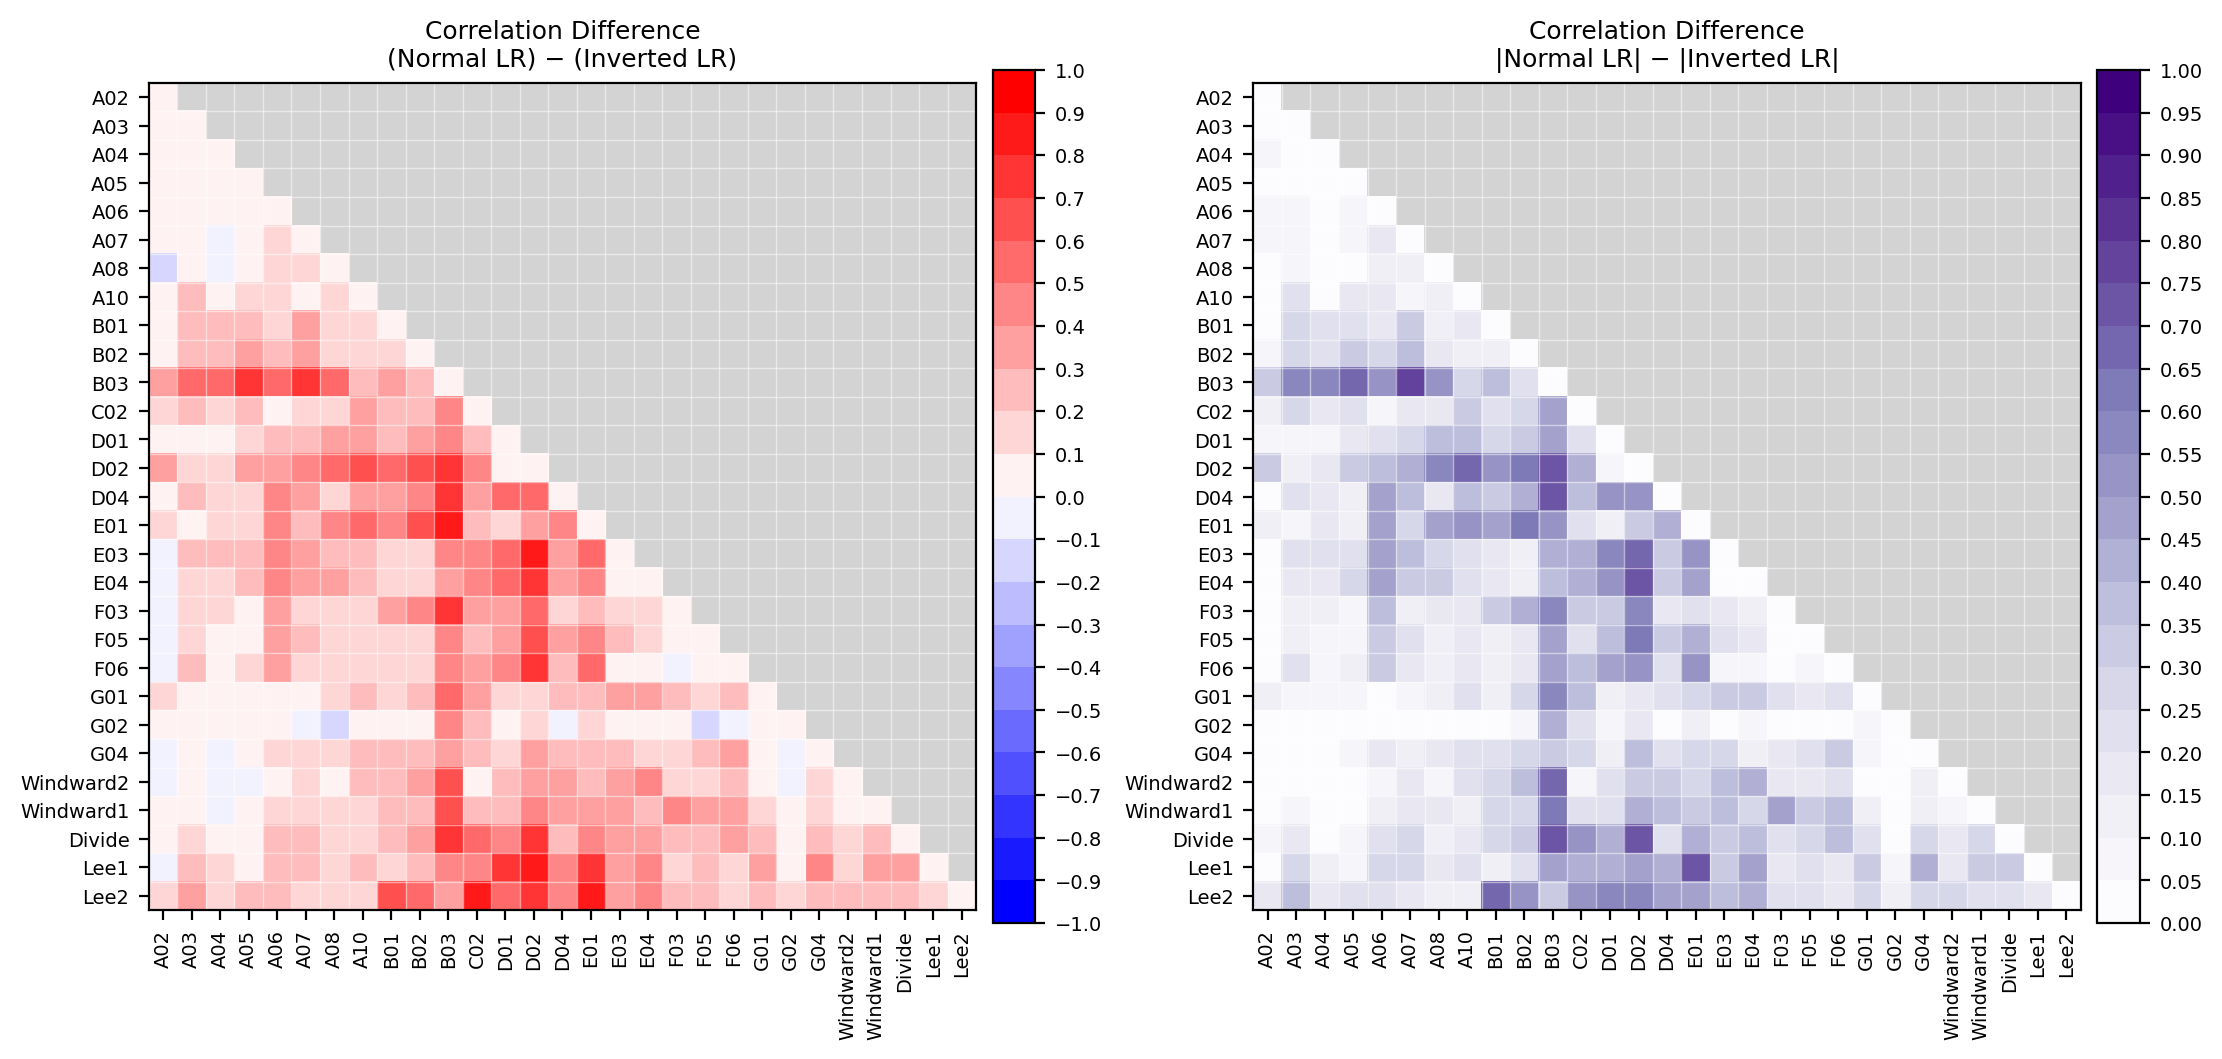

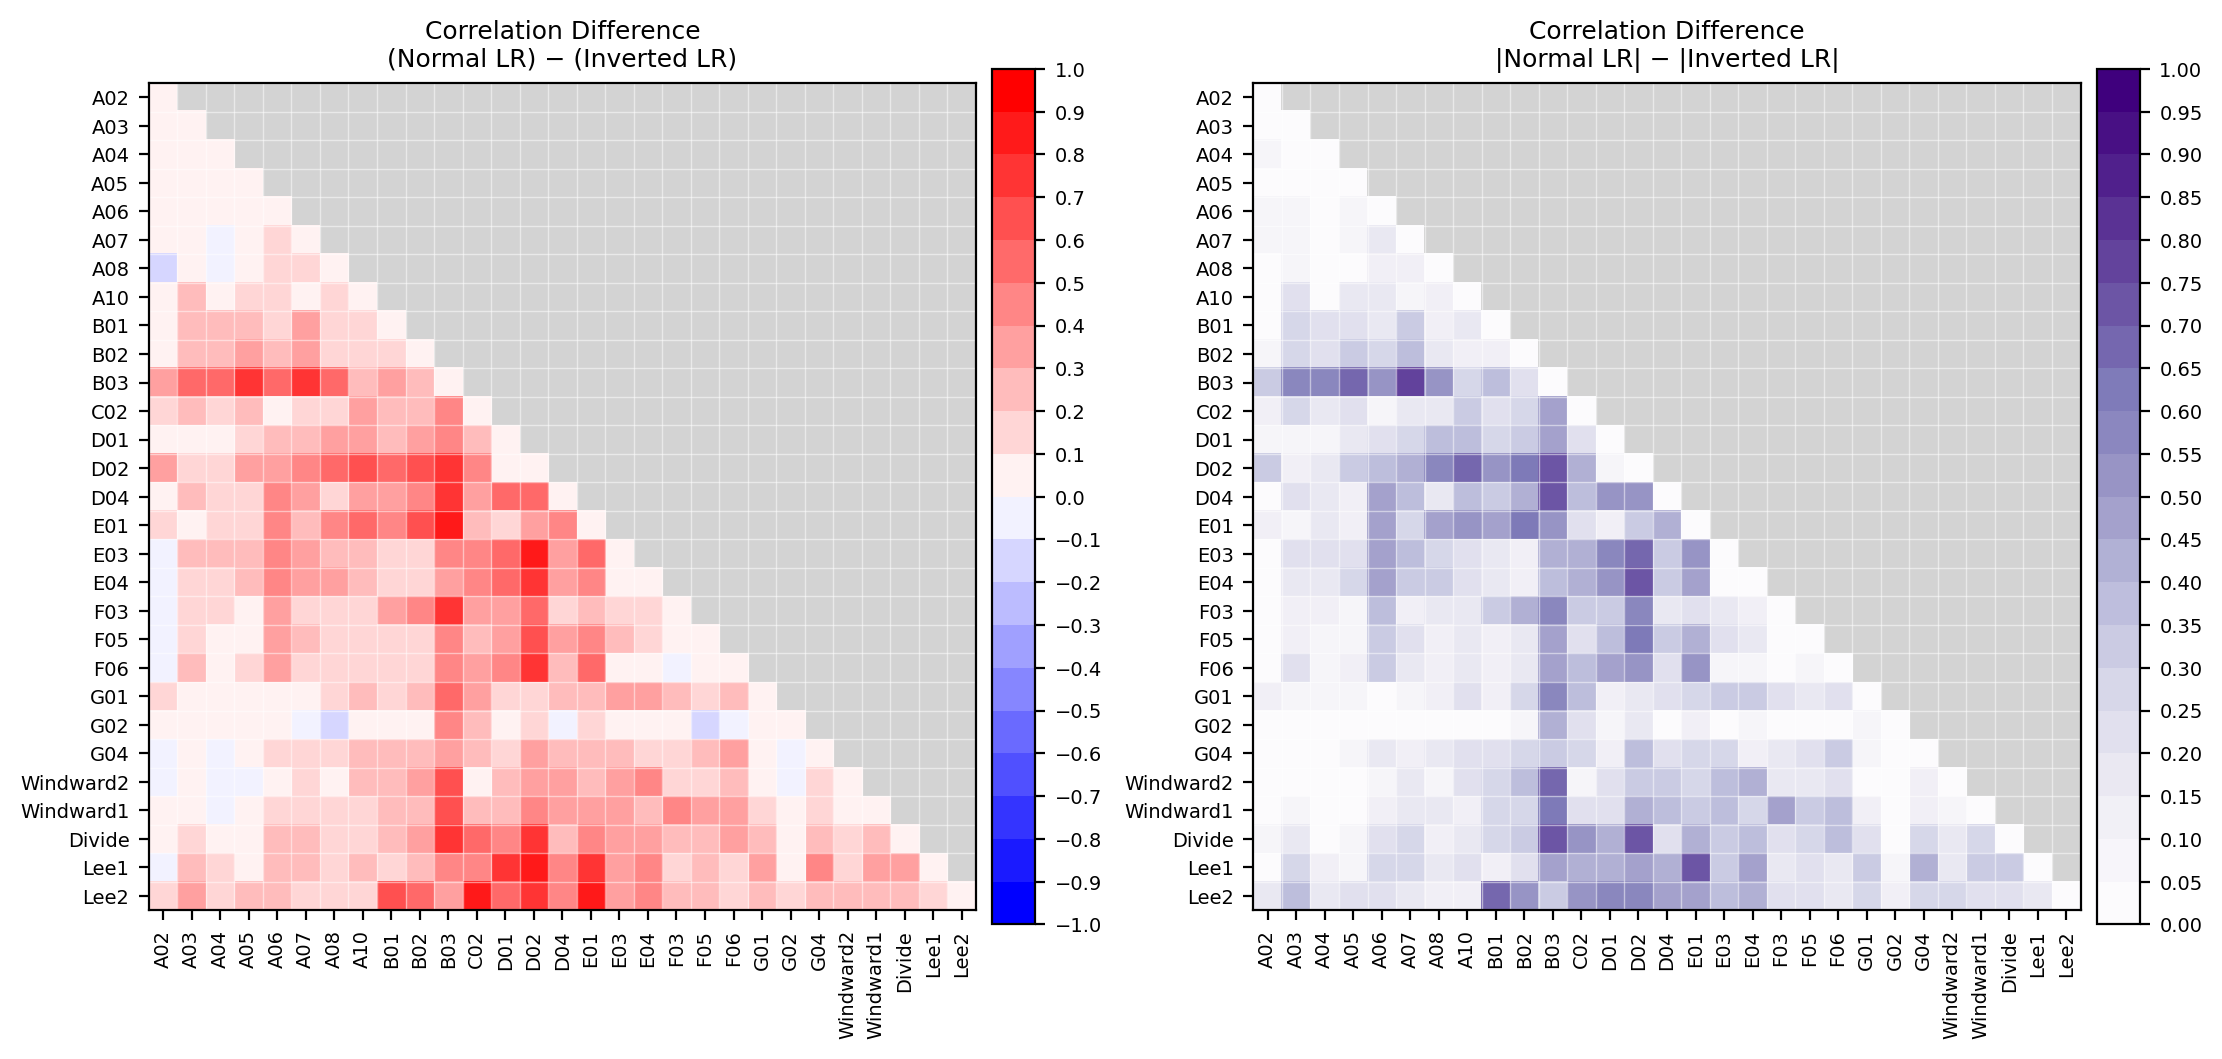

In [101]:
# Pairwise correlation difference: actual and absolute magnitude, 2-column figure
def plot_pairwise_correlation_diff(
    da_pendant_1h, da_intensive_1h, lapse_rate, site_order, output_path,
    n_levels=20,
):
    """2-column difference heatmap.

    Left: actual difference (LR>0) - (LR<0), coolwarm, -1 to 1.
    Right: absolute magnitude difference |LR>0| - |LR<0|, Purples, 0 to 1.
    """
    df = build_site_df(da_pendant_1h, da_intensive_1h)

    lr_series = pd.Series(
        lapse_rate.values, index=pd.DatetimeIndex(lapse_rate.datetime.values)
    )
    lr_aligned = lr_series.reindex(df.index, method="nearest", tolerance=pd.Timedelta("30min"))

    corr_pos = df[lr_aligned > 0].dropna(how="all").corr(method="pearson").loc[site_order, site_order]
    corr_neg = df[lr_aligned < 0].dropna(how="all").corr(method="pearson").loc[site_order, site_order]

    panels = [
        (corr_pos - corr_neg,           "bwr", -1, 1, "(Normal LR) − (Inverted LR)"),
        (corr_pos.abs() - corr_neg.abs(), "Purples",   0, 1, "|Normal LR| − |Inverted LR|"),
    ]

    n = len(site_order)
    tri_mask = np.triu(np.ones((n, n), dtype=bool), k=1)

    fig, axes = plt.subplots(1, 2, figsize=(11, 5.5), dpi=200, layout="constrained")

    for ax, (diff, cmap, vmin, vmax, title) in zip(axes, panels):
        plot_vals = np.where(tri_mask, np.nan, diff.values)
        discrete_cmap, norm = make_discrete_cmap(cmap, n_levels, vmin, vmax)
        ax.set_facecolor("lightgrey")
        im = _draw_heatmap_discrete(ax, plot_vals, diff, discrete_cmap, norm)
        ax.set_xticks(np.arange(n) - 0.5, minor=True)
        ax.set_yticks(np.arange(n) - 0.5, minor=True)
        ax.grid(which="minor", color="white", linewidth=0.5)
        ax.tick_params(which="minor", length=0)
        ax.set_title(f"Correlation Difference\n{title}", fontsize=9)
        fig.colorbar(im, ax=ax, shrink=0.8, pad=0.02, ticks=np.linspace(vmin, vmax, n_levels + 1)).ax.tick_params(labelsize=7)

    #fig.suptitle("Pairwise Correlation Difference (Maritime LR)", fontsize=10)
    fig.savefig(output_path)
    plt.show()
    return fig


plot_pairwise_correlation_diff(
    da_1h,
    da_int_1h,
    lapse_rate=branch_lapse_rates["Maritime"],
    site_order=site_order,
    output_path=output_dir / "all_sites_pairwise_correlation_lr_diff.png",
)


In [104]:
# Summary tables: per-station average correlations from difference plots
def _corr_summary_tables(da_pendant_1h, da_intensive_1h, lapse_rate, site_order, n_top=10):
    df = build_site_df(da_pendant_1h, da_intensive_1h)

    lr_series = pd.Series(
        lapse_rate.values, index=pd.DatetimeIndex(lapse_rate.datetime.values)
    )
    lr_aligned = lr_series.reindex(df.index, method='nearest', tolerance=pd.Timedelta('30min'))

    corr_pos = df[lr_aligned > 0].dropna(how='all').corr(method='pearson').loc[site_order, site_order]
    corr_neg = df[lr_aligned < 0].dropna(how='all').corr(method='pearson').loc[site_order, site_order]

    diff = corr_pos - corr_neg
    abs_diff = corr_pos.abs() - corr_neg.abs()

    n = len(site_order)
    records = {}
    for i, site in enumerate(site_order):
        normal_vals, inv_vals, diff_vals, abs_diff_vals = [], [], [], []
        for j in range(n):
            if i == j:
                continue
            row, col = (i, j) if i > j else (j, i)
            normal_vals.append(corr_pos.iloc[row, col])
            inv_vals.append(corr_neg.iloc[row, col])
            diff_vals.append(diff.iloc[row, col])
            abs_diff_vals.append(abs_diff.iloc[row, col])
        records[site] = {
            'Avg Corr (Normal LR)': np.nanmean(normal_vals),
            'Avg Corr (Inversion)': np.nanmean(inv_vals),
            'Avg Corr Difference': np.nanmean(diff_vals),
            'Avg |Corr| Difference': np.nanmean(abs_diff_vals),
        }

    return pd.DataFrame(records).T.rename_axis('site')


stats_df = _corr_summary_tables(
    da_1h,
    da_int_1h,
    lapse_rate=branch_lapse_rates['Maritime'],
    site_order=site_order,
)

cols = stats_df.columns.tolist()
for col in cols:
    top = stats_df.nlargest(10, col)
    bot = stats_df.nsmallest(10, col)
    print(f'--- Ranked by: {col} ---')
    display(top.style.format('{:.3f}').set_caption(f'Top 10 (highest {col})'))
    display(bot.style.format('{:.3f}').set_caption(f'Bottom 10 (lowest {col})'))


--- Ranked by: Avg Corr (Normal LR) ---


/var/folders/bb/wssqxcxj4tgg0s9fdw74731m0000gn/T/ipykernel_95849/3125775610.py:4: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'datetime' ('datetime',) The recommendation is to set join explicitly for this case.
  da_all = xr.concat([da_pendant_1h, da_intensive_1h], dim="sensor_idx")


,Avg Corr (Normal LR),Avg Corr (Inversion),Avg Corr Difference,Avg |Corr| Difference
site,,,,
B02,0.809,0.530,0.279,0.279
G04,0.804,0.616,0.188,0.188
Windward2,0.784,0.601,0.183,0.183
A07,0.781,0.570,0.211,0.211
B01,0.781,0.536,0.245,0.245
Divide,0.780,0.498,0.282,0.282
A06,0.776,0.545,0.231,0.231
D02,0.766,0.281,0.485,0.453
E01,0.762,0.382,0.380,0.354


,Avg Corr (Normal LR),Avg Corr (Inversion),Avg Corr Difference,Avg |Corr| Difference
site,,,,
A10,0.671,0.455,0.217,0.217
Lee2,0.680,0.342,0.338,0.307
F06,0.685,0.465,0.221,0.215
G02,0.686,0.639,0.047,0.047
Lee1,0.686,0.375,0.311,0.285
A02,0.688,0.641,0.047,0.047
F03,0.693,0.471,0.222,0.217
E04,0.720,0.437,0.283,0.283
G01,0.724,0.540,0.184,0.184


--- Ranked by: Avg Corr (Inversion) ---


...

,Avg Corr (Normal LR),Avg Corr (Inversion),Avg Corr Difference,Avg |Corr| Difference
site,,,,
B03,0.757,0.229,0.528,0.507
D02,0.766,0.281,0.485,0.453
E01,0.762,0.382,0.380,0.354
Lee2,0.680,0.342,0.338,0.307
D04,0.747,0.429,0.318,0.318
Lee1,0.686,0.375,0.311,0.285
C02,0.746,0.439,0.307,0.295
D01,0.739,0.435,0.304,0.295
E03,0.749,0.457,0.292,0.287


,Avg Corr (Normal LR),Avg Corr (Inversion),Avg Corr Difference,Avg |Corr| Difference
site,,,,
G02,0.686,0.639,0.047,0.047
A02,0.688,0.641,0.047,0.047
A04,0.741,0.643,0.098,0.098
A05,0.742,0.599,0.144,0.140
A03,0.738,0.582,0.155,0.155
A08,0.744,0.573,0.171,0.171
Windward2,0.784,0.601,0.183,0.183
G01,0.724,0.540,0.184,0.184
G04,0.804,0.616,0.188,0.188


--- Ranked by: Avg |Corr| Difference ---


,Avg Corr (Normal LR),Avg Corr (Inversion),Avg Corr Difference,Avg |Corr| Difference
site,,,,
B03,0.757,0.229,0.528,0.507
D02,0.766,0.281,0.485,0.453
E01,0.762,0.382,0.380,0.354
D04,0.747,0.429,0.318,0.318
Lee2,0.680,0.342,0.338,0.307
D01,0.739,0.435,0.304,0.295
C02,0.746,0.439,0.307,0.295
E03,0.749,0.457,0.292,0.287
Lee1,0.686,0.375,0.311,0.285


,Avg Corr (Normal LR),Avg Corr (Inversion),Avg Corr Difference,Avg |Corr| Difference
site,,,,
G02,0.686,0.639,0.047,0.047
A02,0.688,0.641,0.047,0.047
A04,0.741,0.643,0.098,0.098
A05,0.742,0.599,0.144,0.140
A03,0.738,0.582,0.155,0.155
A08,0.744,0.573,0.171,0.171
Windward2,0.784,0.601,0.183,0.183
G01,0.724,0.540,0.184,0.184
G04,0.804,0.616,0.188,0.188
